<a href="https://colab.research.google.com/github/Dreeck/ProyectosML/blob/ProyectoFinal/problema_no_supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importar el Data set**

In [1]:
from google.colab import files
uploaded = files.upload()


Saving diabetes_data.csv to diabetes_data.csv


# **Descarga de Umap para pruebas en el sistema**

In [2]:
pip install umap-learn

# **Librerias utilizadas en el desarrollo del sistema**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP

from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import IsolationForest



# **Primera vista del DataSet**

In [4]:
Diabetes = pd.read_csv('diabetes_data.csv',sep=',', low_memory=False)
Diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# **Eliminación de la variable Clasificadora, Métodos de reducción de Outliers**

In [5]:
features = ['Pregnancies', 'Glucose', 'BloodPressure',
            'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']



X_df = Diabetes[features].copy()
X_df[['SkinThickness','Insulin']] = X_df[['SkinThickness','Insulin']].replace(0, np.nan)

In [6]:
iso = IsolationForest(contamination=0.2, random_state=42)
mask_outliers = iso.fit_predict(X_df) == -1
print("Outliers detectados:", mask_outliers.sum())

X_clean = X_df.loc[~mask_outliers].reset_index(drop=True)
print("Dimensiones tras quitar outliers:", X_clean.shape)


Outliers detectados: 154
Dimensiones tras quitar outliers: (614, 8)


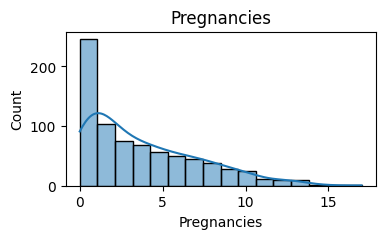

Skew Pregnancies: 0.90



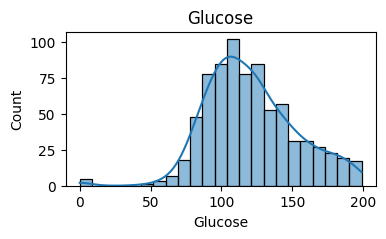

Skew Glucose: 0.17



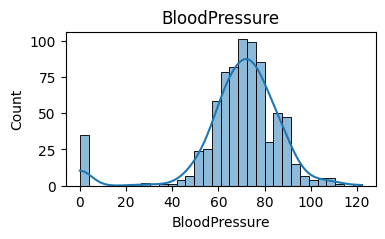

Skew BloodPressure: -1.84



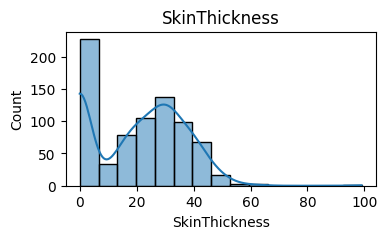

Skew SkinThickness: 0.11



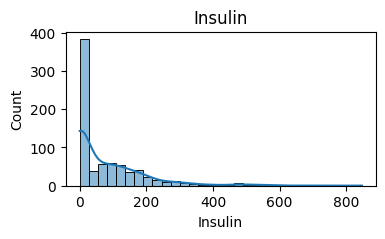

Skew Insulin: 2.27



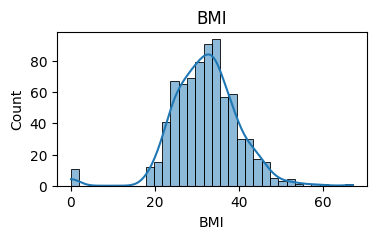

Skew BMI: -0.43



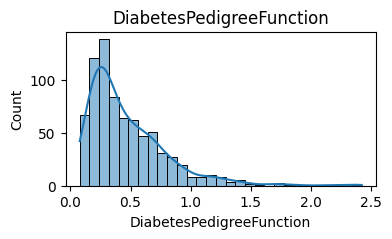

Skew DiabetesPedigreeFunction: 1.92



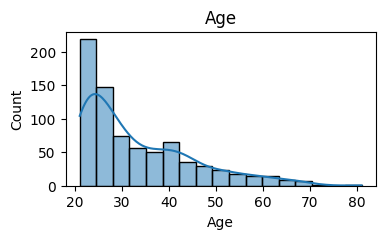

Skew Age: 1.13



In [7]:
for col in features:
    plt.figure(figsize=(4,2))
    sns.histplot(Diabetes[col], kde=True)
    plt.title(col)
    plt.show()
    print(f"Skew {col}: {Diabetes[col].skew():.2f}\n")


# **Resultados Post-Limpieza**

In [8]:
X_clean[['SkinThickness','Insulin']] = (
    X_clean[['SkinThickness','Insulin']]
    .replace(0, np.nan)
)
imputer = KNNImputer(n_neighbors=5)
X_imp = imputer.fit_transform(X_clean)
df_imp = pd.DataFrame(X_imp, columns=X_clean.columns)
print("Ejemplo de filas imputadas:\n", df_imp.head())


Ejemplo de filas imputadas:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    184.6  33.6   
1          1.0     85.0           66.0           29.0     58.6  26.6   
2          8.0    183.0           64.0           28.8    174.6  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          5.0    116.0           74.0           20.6    102.8  25.6   

   DiabetesPedigreeFunction   Age  
0                     0.627  50.0  
1                     0.351  31.0  
2                     0.672  32.0  
3                     0.167  21.0  
4                     0.201  30.0  


In [9]:
pt = PowerTransformer(method='yeo-johnson')
X_pt = pt.fit_transform(X_imp)
df_pt = pd.DataFrame(X_pt, columns=X_clean.columns)
print("Skew después de Yeo–Johnson:")
print(" BloodPressure:", df_pt['BloodPressure'].skew().round(2))
print(" Insulin:      ", df_pt['Insulin'].skew().round(2))

Skew después de Yeo–Johnson:
 BloodPressure: -0.01
 Insulin:       0.01


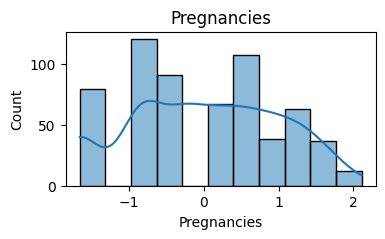

Skew Pregnancies: -0.04



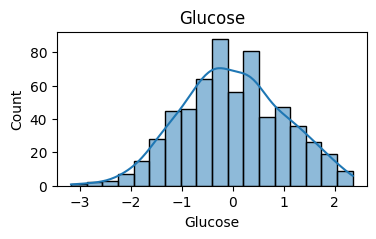

Skew Glucose: 0.00



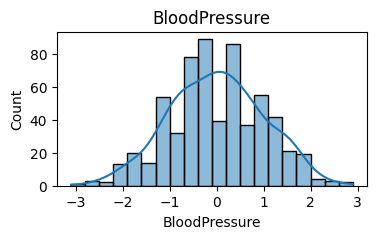

Skew BloodPressure: -0.01



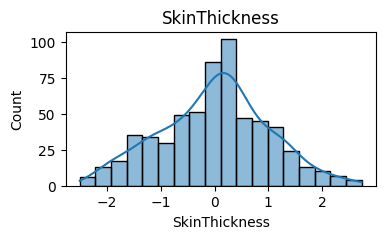

Skew SkinThickness: -0.03



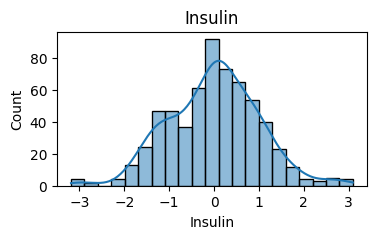

Skew Insulin: 0.01



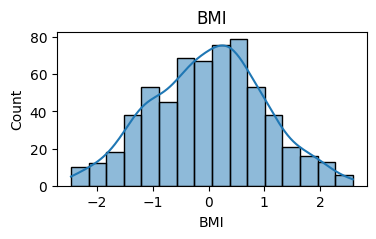

Skew BMI: -0.01



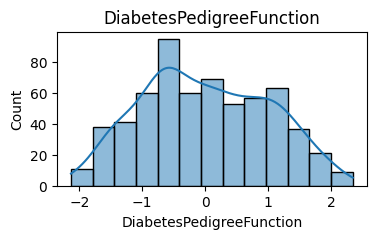

Skew DiabetesPedigreeFunction: 0.11



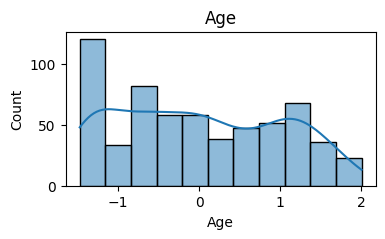

Skew Age: 0.16



In [10]:
for col in features:
    plt.figure(figsize=(4,2))
    sns.histplot(df_pt[col], kde=True)
    plt.title(col)
    plt.show()
    print(f"Skew {col}: {df_pt[col].skew():.2f}\n")


In [11]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_pt)


In [12]:
df_scaled = pd.DataFrame(X_scaled, columns=X_clean.columns)
print("Percentiles [1,99] de cada variable tras escalado:")
print(df_scaled.quantile([0.01,0.99]).T)


Percentiles [1,99] de cada variable tras escalado:
                              0.01      0.99
Pregnancies              -1.142885  1.214445
Glucose                  -1.546989  1.593575
BloodPressure            -1.710497  1.574546
SkinThickness            -1.737274  1.815851
Insulin                  -1.668752  1.939165
BMI                      -1.677817  1.563547
DiabetesPedigreeFunction -1.254332  1.340211
Age                      -0.860899  1.188447


# **Varianza del sistema**

In [13]:
pca3 = PCA(n_components=2, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)
print("Varianza explicada (2 comps):", pca3.explained_variance_ratio_.sum().round(3))


Varianza explicada (2 comps): 0.522


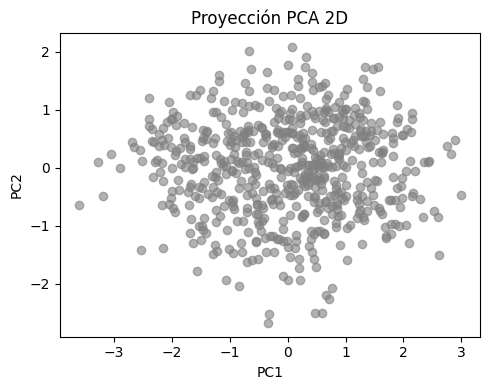

In [14]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(5,4))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c='gray', alpha=0.6)
plt.title("Proyección PCA 2D")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# **Clasificador según el mejor valor utilizable para K**

Resultados por k:
     k  silhouette    calinski
0   2    0.402529  523.323150
1   3    0.357721  467.112159
2   4    0.355447  486.975208
3   5    0.331033  464.833483
4   6    0.356573  483.150389
5   7    0.359656  488.635711
6   8    0.355060  490.362093
7   9    0.344585  471.172025
8  10    0.337650  461.364516


<Axes: xlabel='k'>

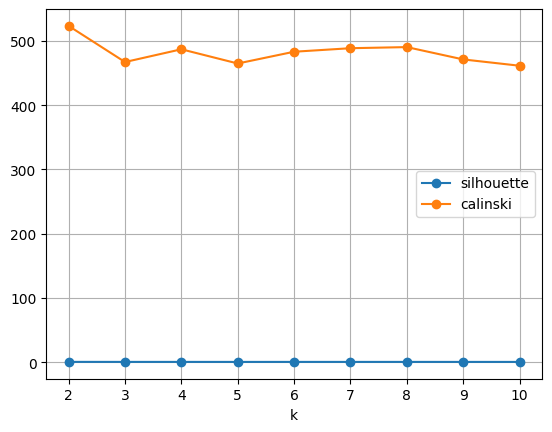

In [15]:
results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_pca3)
    sil = silhouette_score(X_pca3, labels)
    cal = calinski_harabasz_score(X_pca3, labels)
    results.append({'k': k, 'silhouette': sil, 'calinski': cal})

df_res = pd.DataFrame(results)
print("Resultados por k:\n", df_res)
# Puedes graficar:
df_res.plot(x='k', y=['silhouette','calinski'], marker='o', grid=True)


In [16]:
best_k = int(df_res.sort_values('silhouette', ascending=False).iloc[0]['k'])
print(f"\nMejor k según Silhouette: {best_k}")

km_final = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
cluster_labels = km_final.fit_predict(X_pca3)




Mejor k según Silhouette: 2


In [17]:
variances = []
silhouettes = []


for n_comp in range(2, X_scaled.shape[1]+1):
    pca = PCA(n_components=n_comp, random_state=42)
    X_p = pca.fit_transform(X_scaled)
    km = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_p)

    variances.append(pca.explained_variance_ratio_.sum())
    silhouettes.append(silhouette_score(X_p, labels))

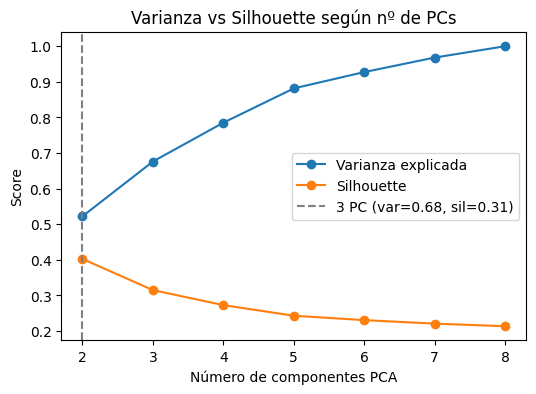

In [18]:
plt.figure(figsize=(6,4))
plt.plot(range(2, X_scaled.shape[1]+1), variances, label='Varianza explicada', marker='o')
plt.plot(range(2, X_scaled.shape[1]+1), silhouettes, label='Silhouette', marker='o')
plt.axvline(x=X_pca3.shape[1], color='grey', linestyle='--',
            label=f'3 PC (var={variances[1]:.2f}, sil={silhouettes[1]:.2f})')
plt.xlabel("Número de componentes PCA")
plt.ylabel("Score")
plt.legend()
plt.title("Varianza vs Silhouette según nº de PCs")
plt.show()


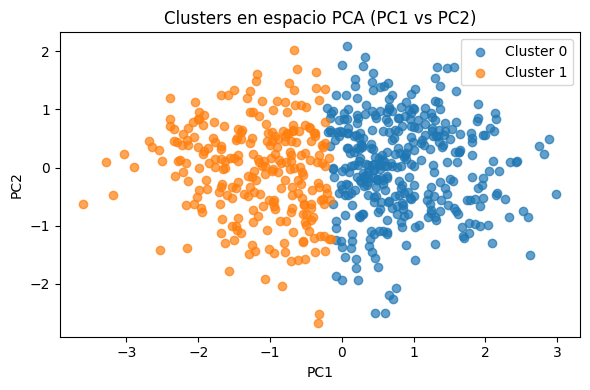

In [23]:
plt.figure(figsize=(6,4))
for c in sorted(df_pca['cluster'].unique()):
    mask = df_pca['cluster'] == c
    plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                label=f"Cluster {c}", alpha=0.7)
plt.legend()
plt.title("Clusters en espacio PCA (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


# **Resultados**

In [19]:
df_orig = X_clean.copy()
df_orig['cluster'] = cluster_labels
print("\nMedias por cluster (variables originales):")
print(df_orig.groupby('cluster').mean().round(2))



Medias por cluster (variables originales):
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
cluster                                                                       
0               4.32   130.54          74.81          34.26   188.45  34.85   
1               2.41   100.68          66.13          22.13    91.37  28.05   

         DiabetesPedigreeFunction    Age  
cluster                                   
0                            0.45  34.72  
1                            0.41  26.11  


In [20]:
pc_cols = [f"PC{i+1}" for i in range(X_pca3.shape[1])]
df_pca = pd.DataFrame(X_pca3, columns=pc_cols)
df_pca['cluster'] = cluster_labels
print("\nMedias por cluster (PCs):")
print(df_pca.groupby('cluster').mean().round(3))




Medias por cluster (PCs):
           PC1    PC2
cluster              
0        0.841  0.031
1       -1.176 -0.044


In [21]:
df = Diabetes.loc[X_clean.index].copy()
df['cluster'] = labels
print(df.groupby('cluster')['Outcome'].value_counts(normalize=True))


cluster  Outcome
0        0          0.662921
         1          0.337079
1        0          0.639535
         1          0.360465
Name: proportion, dtype: float64
